In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rapidfuzz import process
import re
import seaborn as sns
from wordcloud import WordCloud
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer

nlp = spacy.load("en_core_web_sm")

# Contextualização

* Arquivos relacionados a Jeffrey Epstein, financista acusado de tráfico sexual de menores
* Investigado por manter uma rede de exploração envolvendo pessoas influentes
* Preso em 2019 e encontrado morto enquanto aguardava julgamento
* Documentos incluem: e-mails, fotos, contatos, registros judiciais, histórico de viagens e depoimentos
* Parte do material veio de processos como o de Ghislaine Maxwell, sua associada


* Os dados foram retirados das divulgações Volume 9-12 do Departamento de Justiça Americano. Fizemos análises com base nos e-mails e no histórico de viagens presentes nos arquivos.
* Contamos com 3652 viagens e 2322 e-mails
* 4509 pessoas citadas
* 328 lugares diferentes visitados
* 326 crimes cometidos

# Estrutura dos dados

### setup

In [6]:
flights = pd.read_csv('epstein-flights-2026-04-01.csv')
flights = flights.rename(columns={'Date': 'date', 'Origin': 'origin', 'Destination': 'destination', 'Aircraft': 'aircraft', 'Passengers': 'passengers', 'Pilot': 'pilot', 'Notes': 'notes'})
flights = flights.sort_values(by='date', ascending=True).reset_index(drop=True)
flights['date'] = pd.to_datetime(flights['date'])

In [7]:
emails = pd.read_json('emails_with_metadata.json')
emails = emails.sort_values(by='date', ascending=True).reset_index(drop=True)

In [36]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z]+', ' ', text)

    doc = nlp(text)
    processed_tokens = []

    for token in doc:
        if not token.is_stop and not token.is_punct and len(token.text) > 2:
            processed_tokens.append(token.lemma_)

    return " ".join(processed_tokens)

In [43]:
def last_match(text):
    last_pos = 0
    for match in re.finditer(r'((wrote:)|(To:)|(Subject:)|(Importance:)|(Sent:(.|\n)*?(AM|PM))).*?\n', text):
        last_pos = match.end()
    return text[last_pos:]

In [44]:
emails['email_text'] = emails['email_text'].apply(last_match).str.replace('\n', ' ')

# Análise exploratória

## Volume ao longo do tempo

<Axes: xlabel='date'>

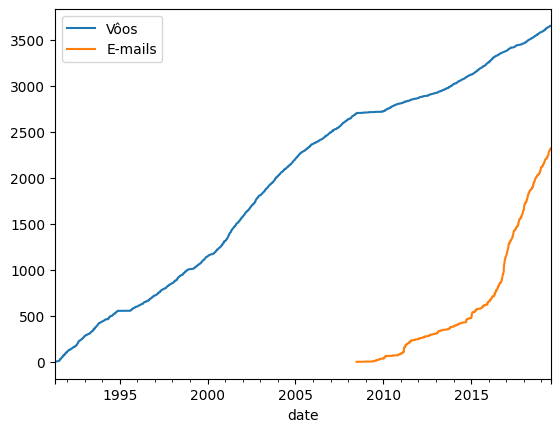

In [8]:
flights.groupby(['date'])[['origin']].count().cumsum().resample('D').ffill().rename(columns={'origin':'Vôos'}).join(
    emails.groupby(['date'])[['email_text']].count().cumsum().resample('D').ffill().rename(columns={'email_text':'E-mails'}),
    how='outer'
).plot()

<Axes: xlabel='date'>

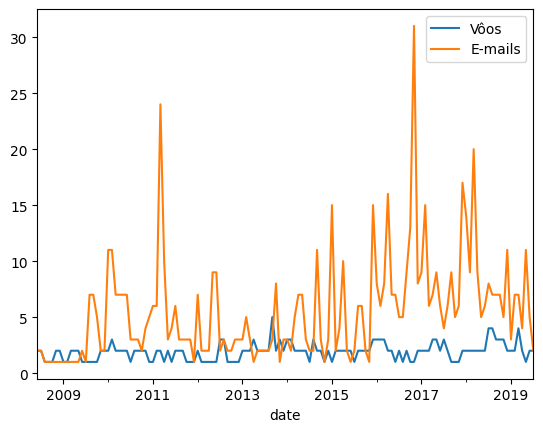

In [52]:
dt = flights.groupby(['date'])[['origin']].count().resample('D').ffill().join(emails.groupby(['date'])[['email_text']].count().resample('D').ffill(), on='date')
dt.to_period('M').groupby(['date']).max()[emails['date'].min():].rename(columns={'email_text':'E-mails', 'origin':'Vôos'}).plot()

## Termos chave

#### setup

In [29]:
names = pd.concat([emails['people_mentioned'].explode(),
                   flights['passengers'].str.split(';').explode()]
                  ).unique()
people = pd.DataFrame(columns=['name', 'email_frequency', 'flight_frequency', 'first_email', 'first_flight'])
people['name'] = names

In [30]:
people['email_frequency'] = people['name'].apply(
     lambda x: 
          emails['people_mentioned']
          .apply(lambda y: x in y)
          .sum())

people['flight_frequency'] = people['name'].apply(
     lambda x: 
          flights['passengers']
          .dropna()
          .str.split(';')
          .apply(
               lambda y: 
                    x in y
               ).sum())

people['first_email'] = people['name'].apply(
     lambda x: 
          emails
          .loc[emails['people_mentioned']
               .apply(lambda y: x in y)
          ].first_valid_index()
     ).apply(
          lambda x: 
               emails.iloc[int(x)]['date'] 
               if not np.isnan(x) 
               else np.nan)
    
people['first_flight'] = people['name'].apply(
     lambda x: 
          flights[['passengers', 'date']].dropna()
     .loc[flights['passengers']
          .dropna()
          .str.split(';')
          .apply(lambda y: x in y)
          ].first_valid_index()
     ).apply(
         lambda x: 
               flights.iloc[int(x)]['date'] 
                    if not np.isnan(x) 
                    else np.nan)

In [31]:
name_map = {
    "trump": "donald trump",
    "jeff epstein": "jeffrey epstein",
    "jeffrey": "jeffrey epstein",
    "donald j. trump": "donald trump"
}

people["name"] = (
    people["name"]
    .str.lower()
    .str.strip()
    .replace(name_map)
)

### Frequência de termos chave

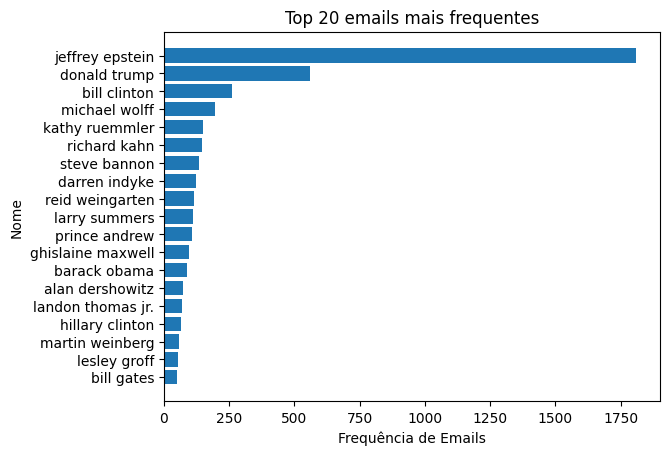

In [32]:
mentioned_names = (
    people[['name', 'email_frequency']]
    .sort_values(by='email_frequency', ascending=False)
    .reset_index(drop=True)
    .head(20)
)

plt.figure()
plt.barh(mentioned_names['name'], mentioned_names['email_frequency'])
plt.gca().invert_yaxis()

plt.xlabel("Frequência de Emails")
plt.ylabel("Nome")
plt.title("Top 20 emails mais frequentes")

plt.show()

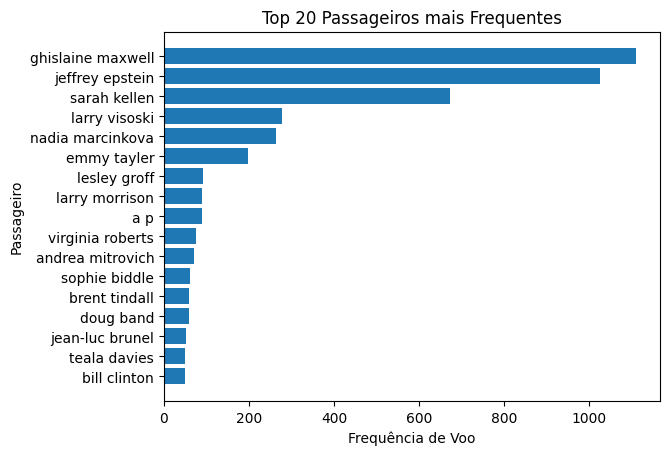

In [33]:
mentioned_names = (
    people[['name', 'flight_frequency']]
    .sort_values(by='flight_frequency', ascending=False)
    .reset_index(drop=True).head(20)
)

plt.figure()
plt.barh(mentioned_names['name'], mentioned_names['flight_frequency'])
plt.gca().invert_yaxis()

plt.xlabel("Frequência de Voo")
plt.ylabel("Passageiro")
plt.title("Top 20 Passageiros mais Frequentes")

plt.show()

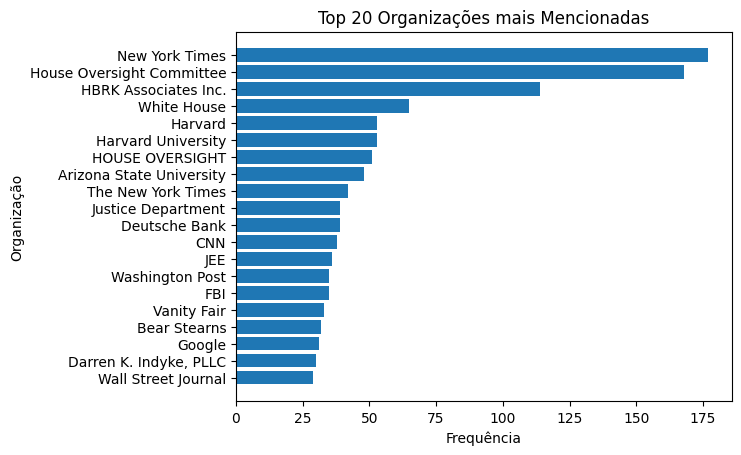

In [34]:
top_orgs = (
    emails["organizations"]
    .explode()
    .dropna()
    .value_counts()
    .head(20)
)

plt.figure()
plt.barh(top_orgs.index, top_orgs.values)
plt.gca().invert_yaxis()

plt.xlabel("Frequência")
plt.ylabel("Organização")
plt.title("Top 20 Organizações mais Mencionadas")

plt.show()

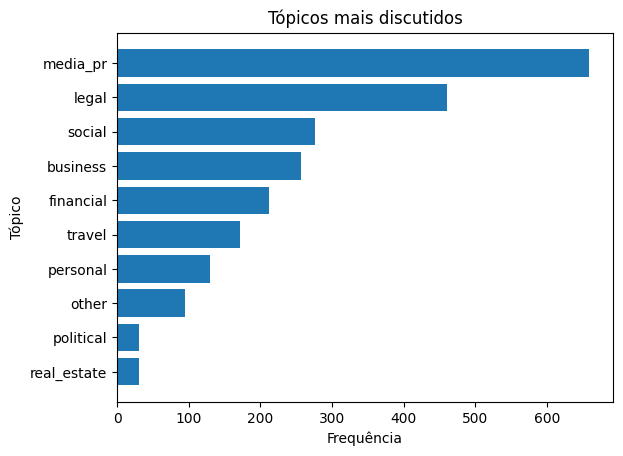

In [ ]:
topics = (
    emails["primary_topic"]
    .explode()
    .dropna()
    .value_counts()
)

plt.figure()
plt.barh(topics.index, topics.values)
plt.gca().invert_yaxis()

plt.xlabel("Frequência")
plt.ylabel("Tópico")
plt.title("Tópicos mais discutidos")

plt.show()

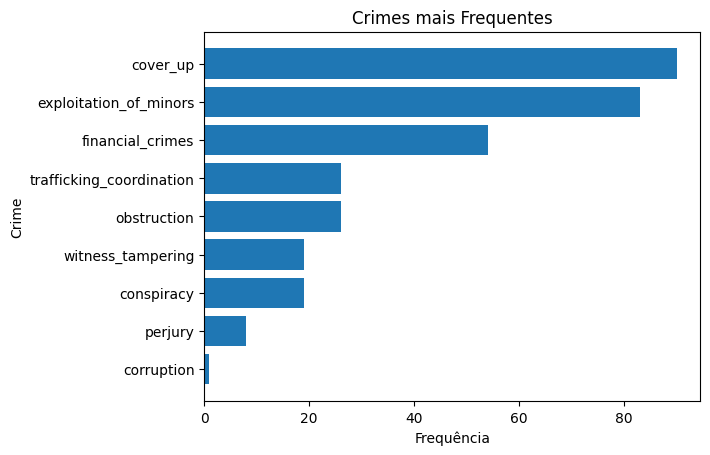

In [ ]:
crimes = (
    emails["crime_types"]
    .explode()
    .dropna()
    .value_counts()
)

plt.figure()
plt.barh(crimes.index, crimes.values)
plt.gca().invert_yaxis()

plt.xlabel("Frequência")
plt.ylabel("Crime")
plt.title("Crimes mais Frequentes")

plt.show()

#### Visualização

In [37]:
def generate_wordclouds(df, text='email_text', category_column=None):
    if category_column is None:
        texts = " ".join(df[text].dropna().apply(preprocess_text))

        wc = WordCloud(background_color="white", width=800, height=400).generate(texts)
        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis("off")
        plt.title("General Wordcloud")
        plt.show()

    else:
        categories = df[category_column].unique()

        for category in categories:
            filtered_df = df[df[category_column] == category]
            texts = " ".join(filtered_df[text].dropna().apply(preprocess_text))

            if not texts.strip():
                continue

            wc = WordCloud(background_color="white", width=800, height=400).generate(texts)
            plt.figure(figsize=(10, 5))
            plt.imshow(wc, interpolation='bilinear')
            plt.axis("off")
            plt.title(f"Wordcloud {category_column} - {category}")
            plt.show()

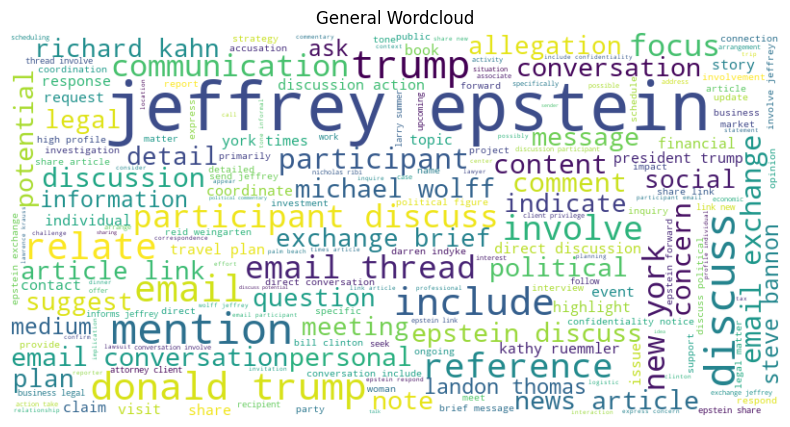

In [38]:
generate_wordclouds(emails, text='summary')

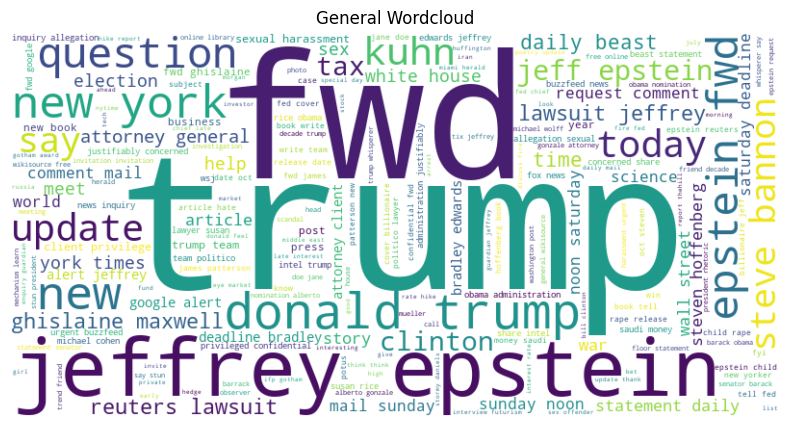

In [39]:
generate_wordclouds(emails, text='subject')

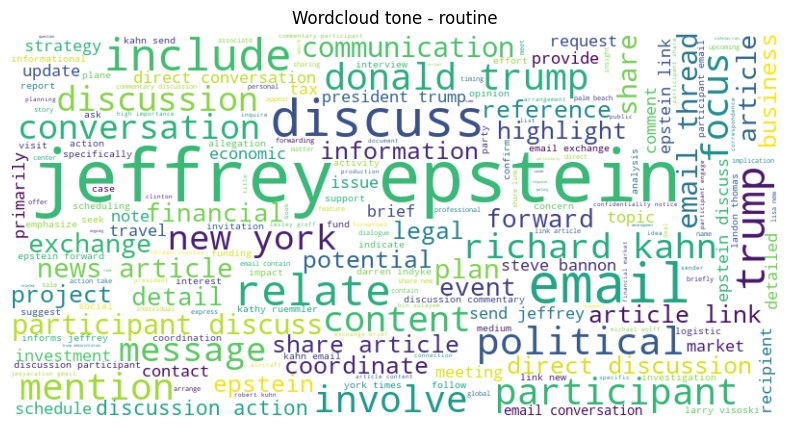

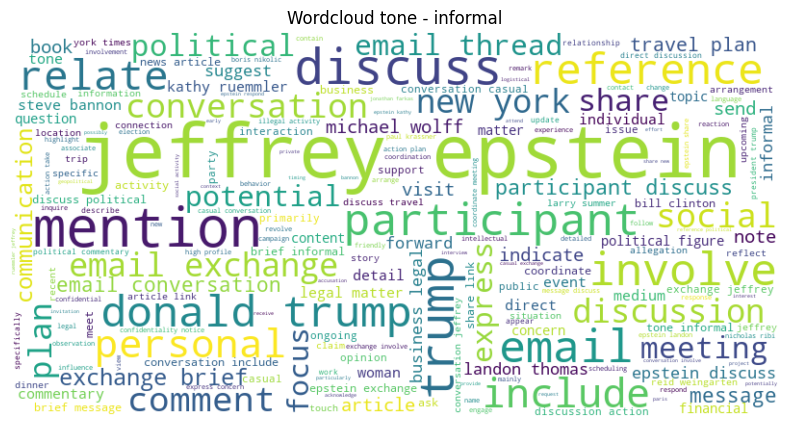

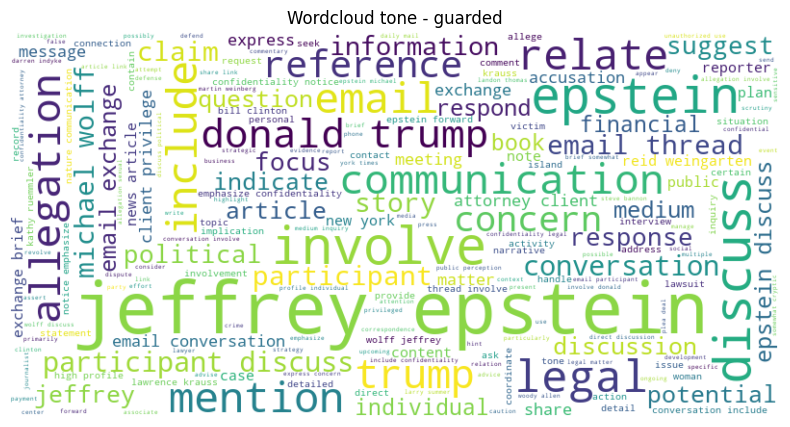

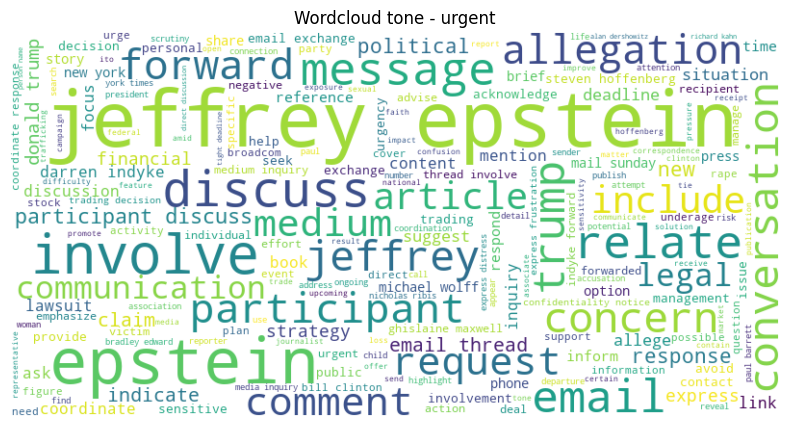

In [40]:
generate_wordclouds(emails, text='summary', category_column='tone')

In [41]:
generate_wordclouds(emails, text='summary', category_column='crime_types')

TypeError: unhashable type: 'list'

### Tipos de email

/tmp/ipykernel_23412/259336374.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


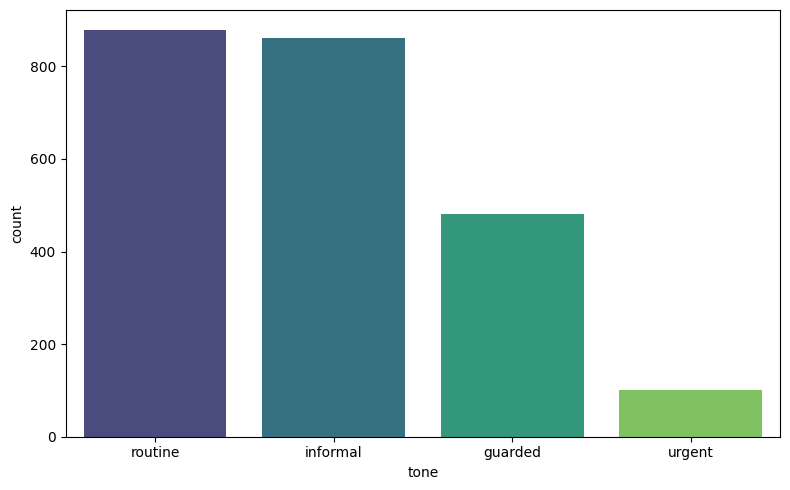

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 5))
sns.countplot(
    data=emails,
    x='tone',
    order=emails['tone'].value_counts().index,
    palette='viridis'
)

plt.tight_layout()

### TF-IDF (Importância de termos)

#### setup

In [45]:
people.loc[(people['email_frequency'] > 0) & (people['flight_frequency'] > 0)]

,name,email_frequency,flight_frequency,first_email,first_flight
20,jeffrey epstein,1810,1005,2009-04-18,1991-07-26
37,bill clinton,260,14,2009-06-19,2002-02-09
65,ghislaine maxwell,96,42,2009-08-11,1992-01-05
102,bill gates,51,1,2009-10-31,2013-03-01
228,gerald lefcourt,10,2,2010-02-26,2006-12-21
245,alan dershowitz,73,3,2010-02-26,2004-02-05
810,jeffrey epstein,5,9,2011-04-26,1991-07-29
1951,larry visoski,44,278,2014-06-07,2001-08-30
3888,john roberts,1,2,2018-11-21,2010-03-22


In [46]:
vectorizer = TfidfVectorizer()
vector = vectorizer.fit_transform(emails['email_text'].apply(preprocess_text))

In [47]:
words = pd.DataFrame(columns=[1,2,3,4,5])

X_tfidf = vector.toarray()
vocab = vectorizer.vocabulary_

reverse_vocab = {v:k for k,v in vocab.items()}

feature_names = vectorizer.get_feature_names_out()

idx = X_tfidf.argsort(axis=1)
tfidf_max5 = idx[:,-5:]

words[[1,2,3,4,5]] = [[reverse_vocab.get(item) for item in row] for row in tfidf_max5 ]

#### Resultados

In [58]:
pd.DataFrame([[[reverse_vocab.get(item) for item in row] for row in tfidf_max5 ]]).transpose().explode(0).value_counts().head(25)

0            
communication    958
thereof          550
mail             488
use              425
information      356
epstein          116
landon           104
thomas            96
timestopic        48
jeffrey           40
nytime            38
utm               36
oversight         35
maxwell           34
asu               31
house             30
krauss            30
origin            29
email             29
message           28
trump             26
sex               26
zynga             25
tax               24
iphone            22
Name: count, dtype: int64